<a href="https://colab.research.google.com/github/pmpatel-udallas/PChemLab/blob/main/PChem_Lab_Day_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transitioning from Excel to Python for Chemistry Lab Data Analysis


Coding is one of the most useful and transferable skills in the modern age. The goal is not to teach you everything about Python, but to give you a gentle introduction through applied learning and practical problem solving so you will be equipped in case you wish to further explore this area.

Just like in experimental labs, it is not always practical to try to understand every detail in full. For example, we consider only the basic fundamentals behind the engineering of the lab instruments like the GC-MS or UV-vis. It is not the best use of our time to fully delve into the materials involved in the construction or the software engineering. As chemists, we are interested in the application and the broad scientific implications.

Likewise, we will try to understand the big picture in our coding labs. Focus on the concepts and implications for your area of chemistry, but pay attention to how the code is doing this.

In [1]:
# @title Overview
%%html
<style>
div.alert {
    color: #0056b3;
    background-color: #d9edf7;
    border-left: 5px solid #31708f;
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
}
div.alert ul {
    margin: 0.5em 0;
}
div.alert li {
    margin-bottom: 0.5em;
}
</style>

<div class="alert alert-block alert-info">
    <strong>Questions:</strong>
    <ul>
        <li>How do we import data from Excel into Python?</li>
        <li>How do we create plots in Python?</li>
        <li>What kind of plots can we create in Python?</li>
    </ul>

    <strong>Objectives:</strong>
    <ul>
        <li>Learn how to import Excel data into Google Colab and into Jupyter Notebooks.</li>
        <li>Learn the basics of plotting using Matplotlib.</li>
        <li>Apply chemistry knowledge to plots created in Matplotlib.</li>
    </ul>
</div>



## Getting Started

In [2]:
# @title Import Packages
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

<p>
In the cell below, hit the play button to the left or press <code>Shift+Enter</code> to run this code to import the packages
</p>

</div>


In [3]:
# Pandas dataframe library
import pandas as pd

# Import standard packages for numerical operations
import numpy as np

# Import plotting packages
import matplotlib.pyplot as plt

# Import standard package for linear regression (generates uncertanties along with results)
import scipy
from scipy import stats

In [4]:
# @title ### Matplotlib Settings
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

  <p>If you want to customize font size and family of your plots by default,
    include the following lines of code and change parameters accordingly
  </p>
    <ul>
        <li><code>import matplotlib as mpl</code></li>
        <li><code>mpl.rcParams.update({'font.size': 20})</code></li>
        <li><code>mpl.rcParams.update({'font.family': 'Arial'})</code></li>
        <li><code>mpl.rcParams.update({'mathtext.fontset' : 'custom'})</code></li>
    </ul>
</div>


# Part 1. How to import data from Excel

Let's get familiar with the basics of plotting and importing data from Excel to Python

In [5]:
# @title Import Tutorial Data (only hit play button below once)
%%capture
%pip install "jupyterquiz"
from jupyterquiz import display_quiz

#Import quizzes and rotation1.json from GitHub
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/Rotation-1-Treatment-of-Data/rotation1.json
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/quiz_utils.py
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/Rotation-1-Treatment-of-Data/Tutorial-Data/IR.csv
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/Rotation-1-Treatment-of-Data/Tutorial-Data/IR.xlsx
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/Rotation-1-Treatment-of-Data/Tutorial-Data/Kinetics.xlsx

import quiz_utils


## 1.1 How to import data using Pandas

### **Putting Files on Google Drive**
Navigate to your Google Drive and upload the tutorial files or folders to Google Drive.

### **Accessing Files From Google Drive in Your Notebook**

We will need to read files that we have stored on Google Drive. We will use a few special lines of code to do this.

You can link your Google Drive by mounting your Google Drive by running the following code (in the cell below).
```
from google.colab import drive
drive.mount('/content/drive')
```
After you run this code, a pop up window will ask you if you allow Google Colab to access Google Drive.
Choose "yes" to these questions.

<img src="https://github.com/act-cms/foundational-modules/blob/main/intro-programming/colab-notebooks/images/google_colab_file_access.png?raw=true">



### Reading/Writing Data

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Getting the File Path
Right click the file name and click "Copy Path".
This will give you the "File Path", or the directions to find the file. We will use this in to tell Python where the file is.

Most data you will find yourself working with will be best placed in a two-dimensional pandas object called a *DataFrame* which is always written with two capital letters. The columns can be accessed by column names and rows can be accessed by indices. This will essentially function as the Python version of an Excel spreadsheet.

We are going to utilize `pd.read_csv()` and `pd.read_excel()`, which reads CSV (.csv) files and Excel Workbooks (.xlsx), respectively.


#### Example: Reading a csv file

In [7]:
pd.read_csv('IR.csv')

,Frequency,Acetone,Acetylacetone,Chloroacetone,Methoxyacetone,Methyl_vinyl_ketone,Phenylacetone
0,0.00,0.291983,-0.288640,4.886660,0.031490,0.508664,0.648523
1,0.05,-0.180050,-0.151648,5.426787,-0.396664,0.206064,0.756728
2,0.10,-0.460529,0.195950,5.093135,0.247857,0.180924,0.387545
3,0.15,0.107185,0.193087,5.238640,0.098132,0.344878,0.479225
4,0.20,0.055122,0.169059,5.141003,0.002309,-0.404520,0.692812
...,...,...,...,...,...,...,...
79996,3999.80,0.114646,0.346295,-0.151197,0.742460,-0.172318,0.437268
79997,3999.85,-0.374845,-0.352802,0.258131,-0.207032,0.320795,-0.512519
79998,3999.90,-0.170739,0.158280,0.158024,-0.107655,-0.221783,0.122744
79999,3999.95,0.101387,-0.089498,-0.170026,-0.141424,-0.278662,-0.287814


In [8]:
pd.read_csv('IR.csv',index_col='Frequency')

,Acetone,Acetylacetone,Chloroacetone,Methoxyacetone,Methyl_vinyl_ketone,Phenylacetone
Frequency,,,,,,
0.00,0.291983,-0.288640,4.886660,0.031490,0.508664,0.648523
0.05,-0.180050,-0.151648,5.426787,-0.396664,0.206064,0.756728
0.10,-0.460529,0.195950,5.093135,0.247857,0.180924,0.387545
0.15,0.107185,0.193087,5.238640,0.098132,0.344878,0.479225
0.20,0.055122,0.169059,5.141003,0.002309,-0.404520,0.692812
...,...,...,...,...,...,...
3999.80,0.114646,0.346295,-0.151197,0.742460,-0.172318,0.437268
3999.85,-0.374845,-0.352802,0.258131,-0.207032,0.320795,-0.512519
3999.90,-0.170739,0.158280,0.158024,-0.107655,-0.221783,0.122744


#### Example: Reading an Excel workbook

In [9]:
pd.read_excel('IR.xlsx',index_col='Frequency')

,Acetone,Acetylacetone,Chloroacetone,Methoxyacetone,Methyl_vinyl_ketone,Phenylacetone
Frequency,,,,,,
0.00,0.291983,-0.288640,4.886660,0.031490,0.508664,0.648523
0.05,-0.180050,-0.151648,5.426787,-0.396664,0.206064,0.756728
0.10,-0.460529,0.195950,5.093135,0.247857,0.180924,0.387545
0.15,0.107185,0.193087,5.238640,0.098132,0.344878,0.479225
0.20,0.055122,0.169059,5.141003,0.002309,-0.404520,0.692812
...,...,...,...,...,...,...
3999.80,0.114646,0.346295,-0.151197,0.742460,-0.172318,0.437268
3999.85,-0.374845,-0.352802,0.258131,-0.207032,0.320795,-0.512519
3999.90,-0.170739,0.158280,0.158024,-0.107655,-0.221783,0.122744


In [10]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation1.json',"intro-2-0")

<IPython.core.display.Javascript object>

In [11]:
# @title Exercise: Pandas Sneak Peak
%%html
<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> We are going to explore the functionality of pandas DataFrames later in the semester,
  but go ahead and do the following tasks in separate cells for a quick sneak peak:</p>
  <li> Assign a variable called <code> IRdata </code> to the data in the IR.csv file.
  Make sure to include <code>index_col</code>.
  </li>
    <li>Use <code>IRdata[['Acetone','Chloroacetone']]</code> to only show the IR data for acetone and chloroacetone.
  </li>
    <li> Use <code> IRdata.idxmax(axis=0) </code> to see the index (row number) of the maximum value in each column.
  </li>
</div>

In [12]:
IRdata=pd.read_csv('IR.csv',index_col='Frequency')

In [13]:
IRdata[['Acetone','Chloroacetone']]

,Acetone,Chloroacetone
Frequency,,
0.00,0.291983,4.886660
0.05,-0.180050,5.426787
0.10,-0.460529,5.093135
0.15,0.107185,5.238640
0.20,0.055122,5.141003
...,...,...
3999.80,0.114646,-0.151197
3999.85,-0.374845,0.258131
3999.90,-0.170739,0.158024


In [14]:
IRdata.idxmax(axis=0)

,0
Acetone,1779.45
Acetylacetone,1651.95
Chloroacetone,1777.65
Methoxyacetone,1783.90
Methyl_vinyl_ketone,1743.70
Phenylacetone,1772.95


In [15]:
 # @title **Question 1**
%%html
<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">
<p>This file includes IR spectra for several molecules. When you run the command
<code>IRdata.idxmax(axis=0)</code>, what are some things about this
data that you may be able to infer?
</p>
Write a brief answer in the markdown cell below.
</div>

<font color=red> **ANSWER**

<font color=red> The results refer to the  most intense IR transition for each molecule. This is based on identifying the index (in this case frequency) of the largest value (or most intense transition). It is reasonable to infer that this peak refers to the primary C=O stretch based on this data and knowledge from Organic Chemistry.

# Part 2. How to plot data in matplotlib

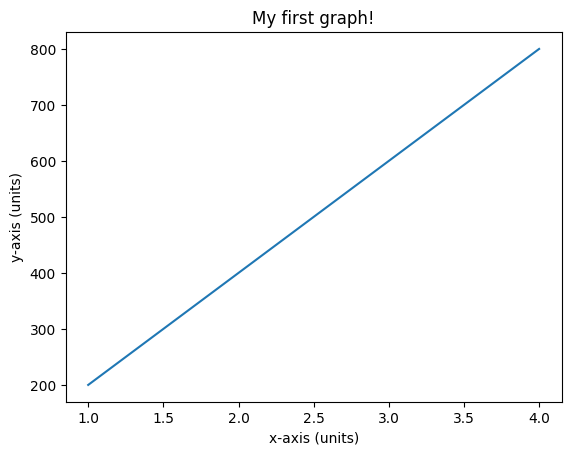

In [16]:
# Simple plots are easy to create and customize

# x axis values
x = [1,2,3,4]

# corresponding y axis values
y = [200,400,600,800]

# plotting the points
plt.plot(x, y)

# naming the x axis
plt.xlabel('x-axis (units)')

# naming the y axis
plt.ylabel('y-axis (units)')

# giving a title to my graph
plt.title('My first graph!')

# function to show the plot
plt.show()

There's plenty of other handy features for plotting, like setting the figure size, font size, x and y axis limits, and much more. Go ahead and take a look at the additional modifications to the graph below. See what changing each of the additions does.

There's a lot of flexibility in the plt.plot function for a wide variety of possible visualization options. For a full description of the options available, refer to the [plt.plot documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html).


In [17]:
# @title Exercise: Fix the graph
%%html
<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
  <p>Something doesn't look right about the plot below. Do the following:
  <ul>
  <li>Fix each one of the changes until the graph looks acceptable.
  </li>
   <li>Play around with the settings in matplotlib to change colors, markers, linestyles, etc.
  </li>
  </ul>
  </p>
  <b> The goal is to start getting comfortable with the aspects of data visualization in Python </b>
</div>


**Table 1.** A Few Common plot Keyword Arguments
<center>

| Argument | Description |
|:------:  | :--------:  |
|`linestyle` or `ls` | line style |
| `marker` | marker style |
|`linewidth` or `lw` | line width |
|`color` or `c` | line color |
|`markeredgecolor` or `mec` | marker edge color |
|`markerfacecolor` or `mfc` | marker color |
|`markersize` or `ms` | marker size |

</center>

**Table 2.** Common Matplotlib Marker Styles (```marker=X```)

<center>


| Argument | Description |
|:-------: | :--------:  |
| 'o'      |  circle |
| '*'    | star |
| 'p'    | pentagon |
| '^'    | triangle |
| 's'    | square   |

</center>

**Table 3.** Common Matplotlib Line Styles (```linestyle=X```)

<center>

| Argument | Description |
|:-------: | :---------: |
|  '-'   | solid |
| '--'   | dashed |
| '-.'   | dash-dot |
| ':'    | dotted |

</center>

**Table 4.** Common Matplotlib Colors (```color=Argument```)

<center>

| Argument | Description |
|:------: | :--------: |
| 'b' | blue |
| 'r' | red  |
| 'k' | black (key) |
| 'g' | green |
| 'm' | magenta |
| 'c' | cyan |
| 'y' | yellow |


</center>

**Table 9.** Legend Location (```loc=Location String/Code```)

<center>

| Location String | Location Code |
|:---------------:| :-----------: |
|'best' (Axes only)|0 |
|'upper right'| 1|
|'upper left'|2|
|'lower left'|3|
|'lower right'|4|
|'right'|5|
|'center left'|6|
|'center right'|7|
|'lower center'|8|
|'upper center'|9|
|'center'|10|

</center>


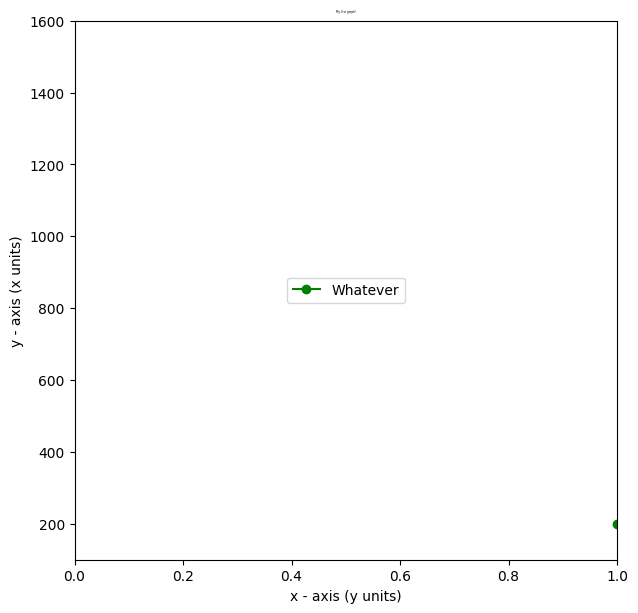

In [18]:
# import the required module
import matplotlib.pyplot as plt

# x axis values
x = [1,2,3,4]
# corresponding y axis values
y = [200,400,600,800]


#this sets the figure size
plt.figure(figsize=(7,7))

#this sets the y and y limits of the figure... but something isn't right!
plt.xlim(0, 1)
plt.ylim(100, 1600)

# plotting the points, note how you can change the marker and color
# You can also use hex codes like '#FFFFFF' in this section.
plt.plot(x, y, '-o', color='green',label='Whatever')

#plot titles
plt.xlabel('x - axis (y units)')
plt.ylabel('y - axis (x units)')
plt.title('My first graph!', fontsize=2)

#Add a legend
plt.legend(loc='center')
plt.show()

### Compute and plot a best fit line

Follow the example below to see how to compute a trend line.

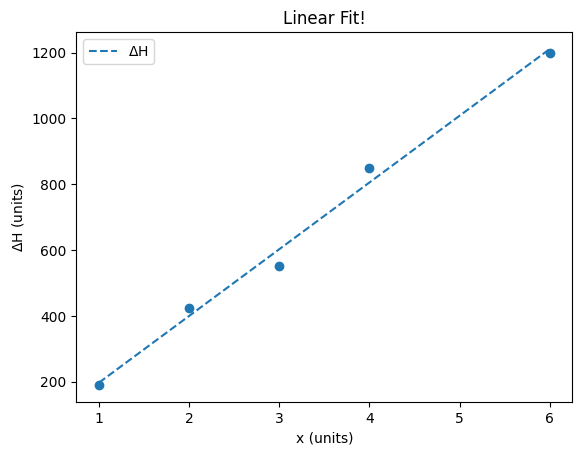

In [19]:
# x, y axis values
x = [1,2,3,4,6]
y = [190,425,550,850,1200]

# plotting the points
plt.plot(x, y, 'o', color='C0')

# make the trend line.
best_fit = scipy.stats.linregress(x, y)
m = best_fit.slope
b = best_fit.intercept
me = best_fit.stderr
mb = best_fit.intercept_stderr
r2 = best_fit.rvalue**2

#plot the best fit line
X = np.linspace(min(x), max(x), 100)
Y = m*X + b
plt.plot(X, Y,'C0--',label=r'$\Delta$H')

#plot titles
plt.xlabel('x (units)')
plt.ylabel(r'$\Delta$H (units)')
plt.title('Linear Fit!', fontsize=12)

# Add a legend
plt.legend()

plt.show()

In [20]:
# @title **Question 2**
%%html
<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">
<li><b>Discuss</b> with your lab partners what you think the above code is doing</li>
<li><b>Write</b> a brief summary in the markdown cell below </li>
</div>

**ANSWER GOES HERE (double click the cell to edit this)**

Delete the text and replace with your answers

### Example 1: Calibration Curve for Beer's Law

Beer's Law relates the absorbance to the concentration
$$A=\varepsilon bc$$
where $A$ is the absorbance (a.u.), $\varepsilon$ is the molar absorptivity coefficient (M$^{-1}$* cm$^{-1}$), $b$ is the path length (1 cm), and $c$ is the concentration (M). Below is a sample plot of a calibration curve and how to determine the concentration of an unknown using the absorbance *graphically*. You will need to determine the concentration of an unknown sample given an absorption measurement *algebraically* using the best fit line.

<center>

  <img src="https://github.com/pmpatel-udallas/CHE-3131/blob/main/Rotation-1-Treatment-of-Data/Tutorial-Data/BeersLaw.png?raw=true" width="50%">

</centger>

In [21]:
# @title Exercise: Calibration Curve Analysis
%%html
<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
Use the sample data for a calibration curve of a UV-vis absorption to plot the calibration curve and do the following:
<ul>
<li> Determine the best fit line parameters</li>
<li> Compute the concentration for a measured absorbance not on the calibration curve using the best fit line parameters </li>
<li> Plot the best fit line on top of the calibration data and include the ordered pair for the computed
  concentration with the measured absorbance</li>
</ul>
</div>

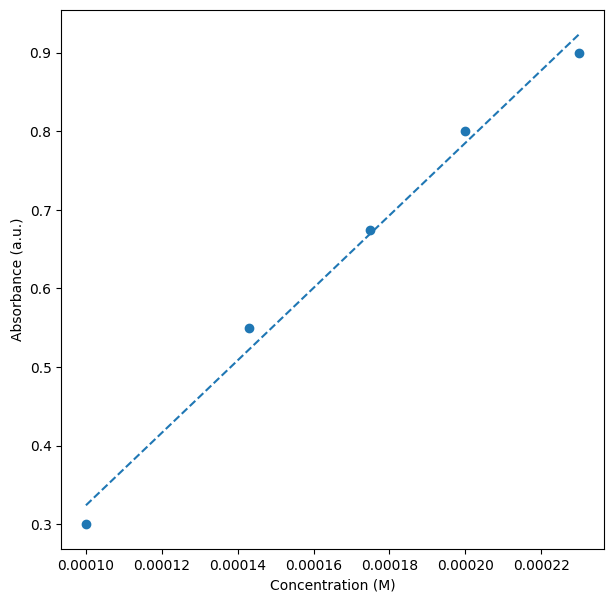

r-squared: 0.9901719532902714
Back-tracked concentration: 0.00018846849086831142


In [22]:
# Known Concentrations
conc = [1e-4,1.43e-4,1.75e-4,2e-4,2.3e-4]

# Measured Absorbances
abs = [0.3,0.55,0.675,0.8,0.9]

# The absorbance measurement of an unknown concentration
unknownABS=0.732

#This sets the figure size, you will need this for exporting images for lab reports
fig = plt.figure(figsize=(7,7))

# ---------------------
best_fit = scipy.stats.linregress(conc,abs)
m = best_fit.slope
b = best_fit.intercept
me = best_fit.stderr
mb = best_fit.intercept_stderr
r2 = best_fit.rvalue**2

# plotting the points
plt.plot(conc, abs, 'o', color='C0')
plt.plot((unknownABS-b)/m,unknownABS,color='C1') # Not required
#plot the best fit line
X = np.linspace(min(conc), max(conc), 100)
Y = m*X + b
plt.plot(X, Y,'C0--',label=r'$\Delta$H')

#plot titles
plt.xlabel('Concentration (M)')
plt.ylabel('Absorbance (a.u.)')
# ---------------------
plt.show()
fig.savefig('BeersLaw.png',dpi=300,bbox_inches='tight')

print('r-squared:',r2)
print('Back-tracked concentration:',(unknownABS-b)/m)

In [23]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation1.json',"intro-2-1")

<IPython.core.display.Javascript object>

### Example 2: Plotting multiple IR spectra

In [24]:
# @title Exercise: Plots
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p>
If the most intense peak in the IR spectrum of acetone corresponds to the carbonyl (C=O) stretch,
how does the position of this peak change when one of the methyl groups is replaced with an
electron-withdrawing group (i.e., in chloroacetone)?
What about for an electron-donating group (i.e., in methoxyacetone)?
</p>

<p>
Using the <code>IRdata</code> DataFrame you imported earlier,
plot the IR spectra of acetone, chloroacetone, and methoxyacetone on the same graph.
Your plot should include the following:
</p>
<ul>
  <li>Clearly labeled axes</li>
  <li>A legend using <code>plt.legend()</code> to identify each molecule</li>
  <li>Default matplotlib colors (feel free to customize if you're confident)</li>
</ul>

</div>

In [25]:
# @title #### Note
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

  <p>Here are some useful lines of code to help visualize this data as you would normally see an IR spectra.
  </p>
  <p><b> You can zoom into a specific region to help answer the questions.
    Keep the ordering of the numbers in xlim in mind when doing so. </b>
  </p>
</div>


```python
plt.xlim(4000,0) # IR spectra: high to low wavenumber
plt.ylim(105,-5) # IR spectra: low to high %T
```

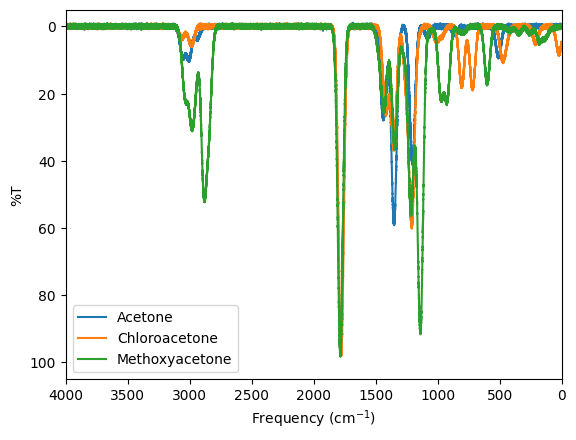

In [26]:
# Your code here
plt.plot(IRdata['Acetone'],label='Acetone')
plt.plot(IRdata['Chloroacetone'],label='Chloroacetone')
plt.plot(IRdata['Methoxyacetone'],label='Methoxyacetone')
plt.ylabel('%T')
plt.xlabel(r'Frequency (cm$^{-1}$)')
plt.legend()
plt.xlim(4000,0) # IR spectra: high to low wavenumber
plt.ylim(105,-5) # IR spectra: low to high %T
plt.show()

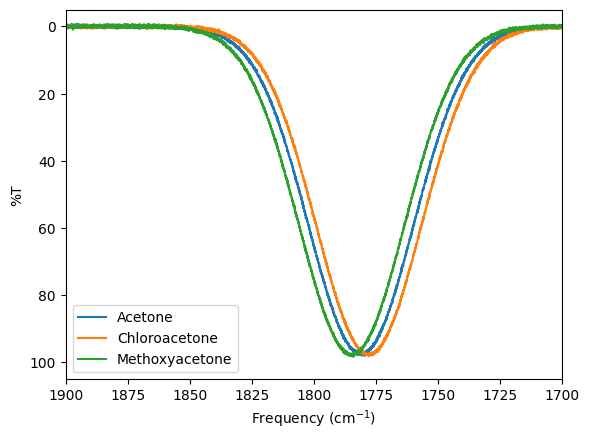

In [27]:
# Zoomed in to see differences in the main peak
plt.plot(IRdata['Acetone'],label='Acetone')
plt.plot(IRdata['Chloroacetone'],label='Chloroacetone')
plt.plot(IRdata['Methoxyacetone'],label='Methoxyacetone')
plt.ylabel('%T')
plt.xlabel(r'Frequency (cm$^{-1}$)')
plt.legend()
plt.xlim(1900,1700) # IR spectra: high to low wavenumber
plt.ylim(105,-5) # IR spectra: low to high %T
plt.show()

In [28]:
# @title **Question 3**
%%html
<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">
<strong>Chemistry Check:</strong>
<p>Use your plotted IR spectra to support your answer to the following questions:
<ul> <li> What does the <strong>direction and magnitude</strong> of the peak shifts
suggest about how the substituent affects the <strong>carbonyl bond strength</strong>? </li> <li>
  Can you explain the observed shifts based on the <strong>inductive effect</strong> of the substituent? </li>
   <li> Keep in mind that <code>chloroacetone</code> contains an <strong>electron-withdrawing group (Cl)</strong>,
while <code>methoxyacetone</code> contains an <strong>electron-donating group (OCH<sub>3</sub>)</strong>. </li> </ul>
</p>

<strong>Note:</strong>
<p>Do not worry if you cannot fully remember the spectroscopy details.
What matters here is learning how to visualize your data when there is no built-in tool
to do it for you.
In many research and real-world settings, you will need to generate and interpret your
own plots to understand the chemistry behind the data, not just the code
or where to click.</p>
</p>
</div>

<font color=red> **ANSWER**

<font color=red>The direction and magnitude of the shifts in the carbonyl stretching frequency reveal how different substituents influence the bond strength of the C=O group. In this case:

<font color=red>Chloroacetone exhibits a higher C=O stretching frequency than acetone.

<font color=red>

1. <font color=red>This suggests that the electron-withdrawing chlorine atom pulls electron density away from the carbonyl carbon via the inductive effect, increasing the partial positive charge on the carbon and strengthening the C=O bond.
2. <font color=red>A stronger bond vibrates at a higher frequency.

<font color=red>Methoxyacetone, on the other hand, shows a lower C=O stretching frequency.
1. <font color=red>The electron-donating methoxy group pushes electron density toward the carbonyl group, reducing the partial positive character on the carbon.</font>
2. <font color=red>This weakens the C=O bond, resulting in a lower-frequency vibration.</font>

<font color=red>Overall, these shifts align well with what we expect based on the inductive effects of substituents:

1. <font color=red>Electron-withdrawing groups (like Cl) - $\uparrow$ C=O frequency (stronger bond)</font>

2. <font color=red>Electron-donating groups (like OCH₃) - $\downarrow$ C=O frequency (weaker bond)</font>

### Example 3: Determining Reaction Order

Recall the equations for $\text{0}^\text{th}$, $\text{1}^\text{st}$, and $\text{2}^\text{nd}$ order integrated rate law equations that make a linear plot and the respective formulas to compute the half life.

<center>

| Reaction Order  | &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Integrated Rate Law  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Half Life   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;|
|:------:|:---------------------------------:|:-----:|
| 0th |  $[A] = [A]_0 + kt$ | $t_{1/2}=\dfrac{[A]_0}{2k}$
| 1st |  $ln([A]) = ln([A]_0) -kt$ | $t_{1/2}=\dfrac{ln(2)}{k}$ |
| 2nd |  $\frac{1}{[A]} = \frac{1}{[A]_0} + kt$ | $t_{1/2}=\dfrac{1}{k[A]_0}$ |

</center>

In [29]:
# @title Exercise: Integrated Rate Laws
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">

Consider the following reaction of the rapid decay of a ClO\(\cdot\) radical:
  </p>
$$ 2ClO\cdot \rightarrow Cl_2 + O_2 $$
<b> Determine the reaction order, rate constant, and the half-life of a ClO\(\cdot\) radical by doing the following: </b>
  </p>
    <ul>
        <li>Generate three separate plots using the <code>kinetics_data</code> DataFrame
        to determine the reaction order</li>
        <ul>
          <li>Find the best fit equation with the highest \(r^2\) value</li>
        <li>If you are feeling adventurous, try to create a 1x3 figure
          (<code>plt.subplots</code>) containing each reaction order in a separate plot. The result will be one image with three plots on it.
        </li>
        </ul>
        <li> Determine the rate constant <code>k</code> via analyzing the best fit parameters.</li>
        <li> Determine the half life by using the appropriate formula. Use variables to make your life easier.</li>
        <li> <i> Note that \(ln(x)\) is coded as <code>np.log(x)</code> in Python.
        \(log(x)\) is coded as <code>np.log10(x)</code> in Python.
    </ul>
</div>

In [30]:
kinetics_data=pd.read_excel('Kinetics.xlsx',sheet_name='Sheet1')
kinetics_data

,time (s),[ClO] (M)
0,0.00000,0.000010
1,0.00012,0.000008
2,0.00062,0.000008
3,0.00096,0.000007
4,0.00160,0.000006
5,0.00320,0.000005
6,0.00400,0.000005
7,0.00575,0.000004


r^2 value: 0.8730341434228027


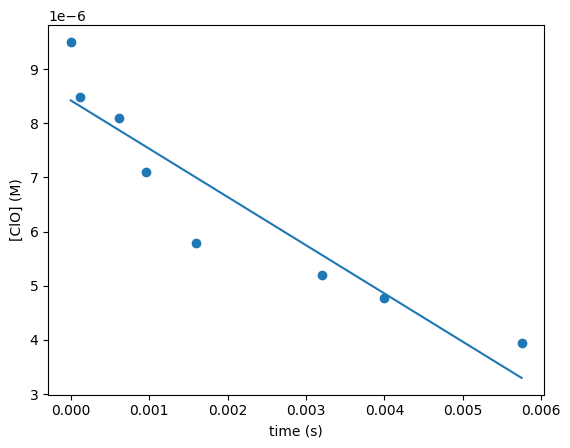

In [31]:
# Zeroth Order Reaction
time=kinetics_data['time (s)']
conc=kinetics_data['[ClO] (M)']

best_fit_0=scipy.stats.linregress(time,conc)
plt.plot(time,best_fit_0.slope*time+best_fit_0.intercept)
plt.plot(time,conc,'C0o')
plt.ylabel('[ClO] (M)')
plt.xlabel('time (s)')
print('r^2 value:',best_fit_0.rvalue**2)

r^2 value: 0.9342640020911587


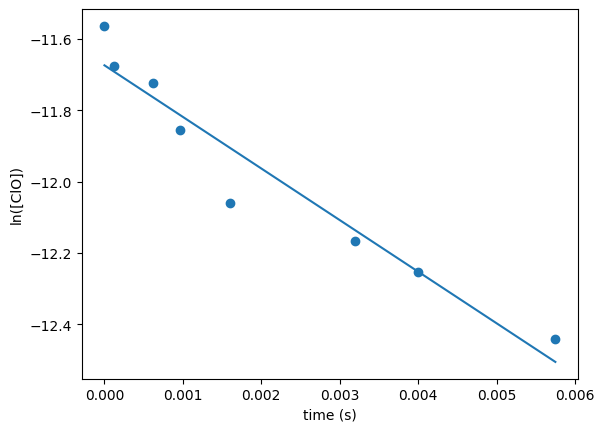

In [32]:
# First Order Reaction
time=kinetics_data['time (s)']
conc=np.log(kinetics_data['[ClO] (M)'])

best_fit_1=scipy.stats.linregress(time,conc)
plt.plot(time,best_fit_1.slope*time+best_fit_1.intercept)
plt.plot(time,conc,'C0o')
plt.ylabel('ln([ClO])')
plt.xlabel('time (s)')
print('r^2 value:',best_fit_1.rvalue**2)

r^2 value: 0.9729398208409403


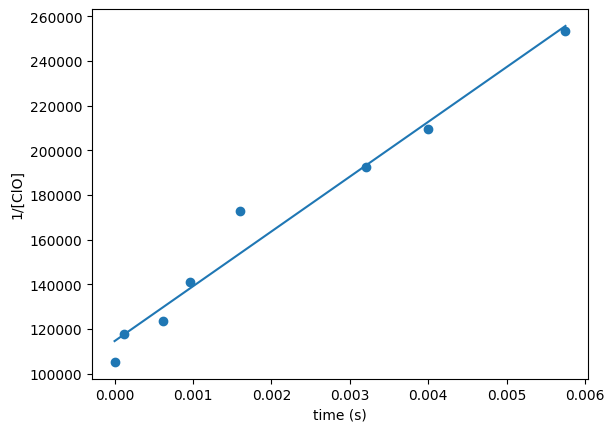

In [33]:
# Second Order Reaction
time=kinetics_data['time (s)']
conc=1/kinetics_data['[ClO] (M)']

best_fit_2=scipy.stats.linregress(time,conc)
plt.plot(time,best_fit_2.slope*time+best_fit_2.intercept)
plt.plot(time,conc,'C0o')
plt.ylabel('1/[ClO]')
plt.xlabel('time (s)')
print('r^2 value:',best_fit_2.rvalue**2)

In [34]:
# Calculate the reaction rate (include units)

# Reaction rate is just the slope
k=best_fit_2.slope
print('k:',"{:.2e}".format(k), 'M^-1s^-1')

k: 2.45e+07 M^-1s^-1


In [39]:
# Calculate the half life

#Using data
t_half=1/(k*kinetics_data['[ClO] (M)'][0])

print('Half life using raw data for 1/A_0:',"{:.2f}".format(t_half*1000), 'ms')

# Using slope and intercept
t_half_2= best_fit_2.intercept/k

print('Half life using slope (k) and intercept (1/A_0):',"{:.2f}".format(t_half_2*1000), 'ms')

Half life using raw data for 1/A_0: 4.29 ms
Half life using slope (k) and intercept (1/A_0): 4.67 ms


In [36]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation1.json',"intro-2-2")

<IPython.core.display.Javascript object>

In [37]:
# @title **Question 4**
%%html
<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">
<b> What are some other types of plots you can make with pandas DataFrames using Matplotlib?
</b>
    <p>Explore the other types of plots you can generate in matplotlib.
      If you want to, practice creating some of the various types of plots available to you.
      There is usually sample code and/or sample data to help get started.</p>


<center>

<a href="https://matplotlib.org/stable/plot_types/index.html">Plot Types in Matplotlib</a>

</center>

<p> Include a paragraph (~5 sentences or 250-300 words) about two different types of plots
  that you have not used or seen before.</p>
</div>

<font color=red> Here are some examples students may choose from the list of available plot types in matplotlib</font>
<font color=red>
1. Violin Plot
2. Contour Plot
3. Quiver Plot
4. 3D surface Plot
5. Stream Plot

<font color=red> This question is graded on completion.</font>

In [38]:
# @title Key Points
%%html
<style>
div.green-note {
    color: #155724; /* Dark green for text */
    background-color: #d4edda; /* Light green background */
    border-left: 5px solid #28a745; /* Bright green border */
    padding: 0.5em;
    font-size: 1.25em; /* Consistent with text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean and modern font */
}
div.green-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.green-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="green-note">
    <strong>Key Points:</strong>
    <ul>
        <li>Import your Excel data with the <code>pd.read_csv()</code> or the <code> pd.read_excel()</code> function</li>
        <li>Construct numerous types of plots with <code> matplotlib </code></li>
        <li>There is a high degree of customizability in <code> matplotlib </code> plots</li>
        <li>The <code>scipy.stats.linregress()</code> function computes best fit line parameters</li>
        <li>There are plenty of applications to use Python to model chemical data</li>
    </ul>
</div>


# References



This notebook includes material from the following sources:

1. <a href="https://act-cms.molssi.org/">act-cms.molssi.org</a>